In [47]:
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import torch

import sys
sys.path.append('../')
from proof_of_concept.models.staged import STAGED
from proof_of_concept.utils.graph_constructor import GraphConstructor
from proof_of_concept.utils.simulated_data_processing import retrieve_simulated_data

from proof_of_concept.tests.test_graph_constructor import create_square_grid_data as create_test_data
from proof_of_concept.utils.visualization import visualize_attention_graph, visualize_graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
data = retrieve_simulated_data(data_dir='../data/raw',sim_file='100_simulation_results.pkl')

In [49]:
data.keys()

dict_keys(['gene_expression', 'cell_positions', 'genes', 'cell_type_assignments', 'prior_grns', 'receptor_gene_pairs', 'ligand_receptor_pairs', 'n_time_points', 'n_cells', 'n_genes'])

In [50]:
for key, value in data.items():
    if isinstance(value, (torch.Tensor, np.ndarray)):
        print(f"{key}: {value.shape}")
    elif isinstance(value, (list, dict)):
        print(f"{key}: length {len(value)}")
    else:
        print(f"{key}: {value}")

gene_expression: torch.Size([100, 10, 6])
cell_positions: torch.Size([100, 10, 2])
genes: length 6
cell_type_assignments: torch.Size([10])
prior_grns: length 2
receptor_gene_pairs: length 4
ligand_receptor_pairs: length 2
n_time_points: 100
n_cells: 10
n_genes: 6


In [51]:
data['genes']

['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5']

In [52]:
data['ligand_receptor_pairs']

[('gene_0', 'gene_3'), ('gene_2', 'gene_1')]

In [53]:
data['cell_type_assignments']

tensor([1, 0, 0, 1, 1, 0, 0, 0, 1, 1])

In [54]:
graph_constructor = GraphConstructor(
    genes=data['genes'],
    ligand_receptor_pairs=data['ligand_receptor_pairs'],
    receptor_gene_pairs=data['receptor_gene_pairs'],
    cell_type_assignments=data['cell_type_assignments'],
    prior_grns=data['prior_grns']
)

# Define time lags as specified by the user
delta_gl = 1  # Time lag for gene -> ligand
delta_lr = 5  # Time lag for ligand -> receptor
delta_rg = 3  # Time lag for receptor -> gene
delta_gg = 1  # Time lag for gene -> gene

time_point = 99

# Ensure time_point is large enough to handle the lags
max_lag = max(delta_gl, delta_lr, delta_rg, delta_gg)
if time_point < max_lag:
    time_point = max_lag
    print(f"Adjusted time_point to {time_point} to handle time lags")


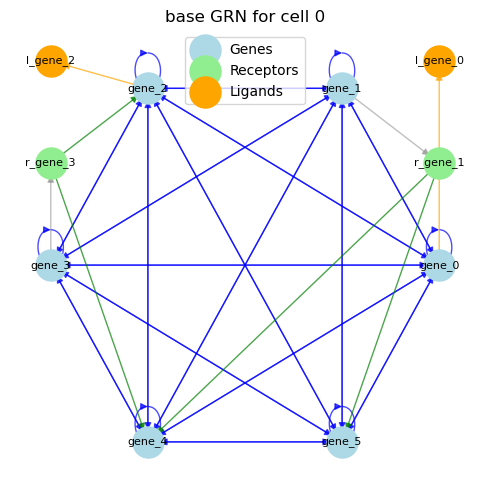

In [55]:
cell_idx = 0
base_graph = graph_constructor.construct_base_graph(cell_idx)
visualize_graph(base_graph, f"base GRN for cell {cell_idx}", save_plot=False, show_plot=True, figsize=(5, 5))

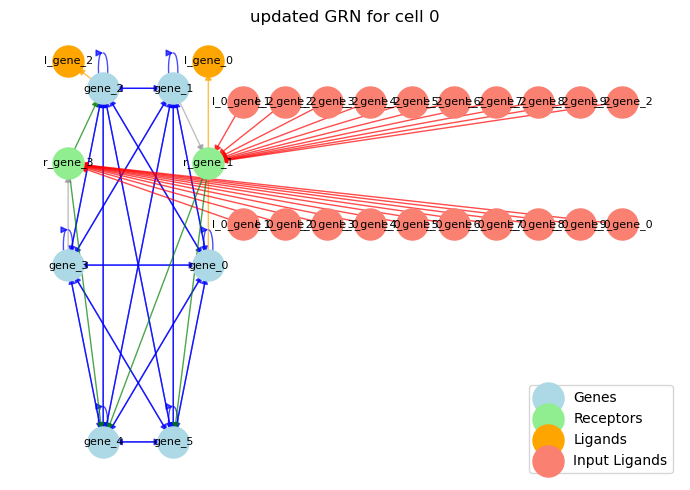

In [56]:
distance_threshold = 10
updated_graph = graph_constructor.update_graph_with_neighbors(
    base_graph, cell_idx, data['cell_positions'], time_point,
    distance_threshold=distance_threshold
)
pos = visualize_graph(updated_graph, f"updated GRN for cell {cell_idx}", save_plot=False, show_plot=True, figsize=(7, 5), return_pos=True)


In [57]:
updated_graph.nodes()

NodeView(('gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'r_gene_1', 'r_gene_3', 'l_gene_0', 'l_gene_2', 'l_0_gene_0', 'l_0_gene_2', 'l_1_gene_0', 'l_1_gene_2', 'l_2_gene_0', 'l_2_gene_2', 'l_3_gene_0', 'l_3_gene_2', 'l_4_gene_0', 'l_4_gene_2', 'l_5_gene_0', 'l_5_gene_2', 'l_6_gene_0', 'l_6_gene_2', 'l_7_gene_0', 'l_7_gene_2', 'l_8_gene_0', 'l_8_gene_2', 'l_9_gene_0', 'l_9_gene_2'))

In [58]:
pyg_graph = graph_constructor.assign_node_features(
    updated_graph, cell_idx, time_point, data['gene_expression'],
    delta_gl, delta_lr, delta_rg, delta_gg
)

In [59]:
pyg_graph

Data(x=[30, 1], edge_index=[2, 64], gene_node_indices=[6], node_names=[30], node_types=[30])

In [60]:
pyg_graph.gene_node_indices

[0, 1, 2, 3, 4, 5]

In [61]:
updated_graph.nodes()

NodeView(('gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'r_gene_1', 'r_gene_3', 'l_gene_0', 'l_gene_2', 'l_0_gene_0', 'l_0_gene_2', 'l_1_gene_0', 'l_1_gene_2', 'l_2_gene_0', 'l_2_gene_2', 'l_3_gene_0', 'l_3_gene_2', 'l_4_gene_0', 'l_4_gene_2', 'l_5_gene_0', 'l_5_gene_2', 'l_6_gene_0', 'l_6_gene_2', 'l_7_gene_0', 'l_7_gene_2', 'l_8_gene_0', 'l_8_gene_2', 'l_9_gene_0', 'l_9_gene_2'))

In [62]:
import os
import pickle

# Load config for future model use
config_path = os.path.join('../results', "config.pkl")
with open(config_path, "rb") as handle:
    config = pickle.load(handle)

In [63]:
config['model_config'].hidden_dim

64

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STAGED(
    num_genes=len(data['genes']),
    hidden_dim=config['model_config'].hidden_dim,
    num_gat_layers=config['model_config'].num_gat_layers,
    num_mlp_layers=config['model_config'].num_mlp_layers,
    dropout=config['model_config'].dropout,
    delta_gl=config['model_config'].delta_gl,
    delta_lr=config['model_config'].delta_lr,
    delta_rg=config['model_config'].delta_rg,
    delta_gg=config['model_config'].delta_gg,
    add_self_loops=config['model_config'].add_self_loops,
).to(device)

In [65]:
import os
import pickle

# Load results object from output directory
model_path = os.path.join('../results', "model.pt")
model.load_state_dict(torch.load(model_path))
model

/var/folders/1r/l8_zwkvx7_g7b632hf_1517c0000gn/T/ipykernel_21403/535133006.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


STAGED(
  (gat_layers): ModuleList(
    (0): GATConv(1, 64, heads=1)
  )
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [66]:
node_embeddings, (edge_index, attention_weights) = model(pyg_graph)

In [67]:
node_embeddings.shape

torch.Size([30, 64])

In [68]:
edge_index.shape

torch.Size([2, 88])

In [69]:
attention_weights.shape

torch.Size([88, 1])

In [70]:
pyg_graph

Data(x=[30, 1], edge_index=[2, 64], gene_node_indices=[6], node_names=[30], node_types=[30])

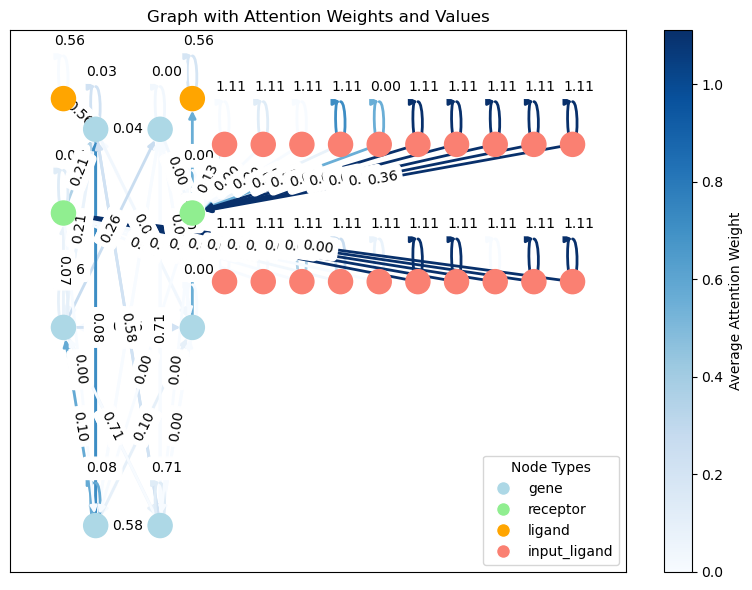

In [71]:
visualize_attention_graph(pyg_graph, edge_index, attention_weights, pos, figsize=(8, 6), show_labels=False)

In [72]:
pyg_graph.node_names

['gene_0',
 'gene_1',
 'gene_2',
 'gene_3',
 'gene_4',
 'gene_5',
 'r_gene_1',
 'r_gene_3',
 'l_gene_0',
 'l_gene_2',
 'l_0_gene_0',
 'l_0_gene_2',
 'l_1_gene_0',
 'l_1_gene_2',
 'l_2_gene_0',
 'l_2_gene_2',
 'l_3_gene_0',
 'l_3_gene_2',
 'l_4_gene_0',
 'l_4_gene_2',
 'l_5_gene_0',
 'l_5_gene_2',
 'l_6_gene_0',
 'l_6_gene_2',
 'l_7_gene_0',
 'l_7_gene_2',
 'l_8_gene_0',
 'l_8_gene_2',
 'l_9_gene_0',
 'l_9_gene_2']

In [73]:
pyg_graph.node_types

['gene',
 'gene',
 'gene',
 'gene',
 'gene',
 'gene',
 'receptor',
 'receptor',
 'ligand',
 'ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand',
 'input_ligand']

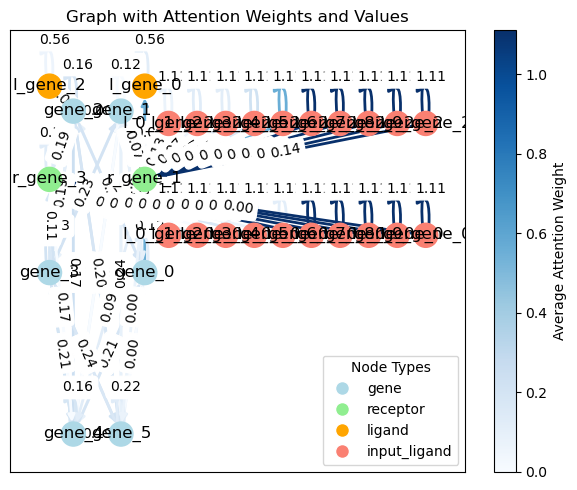

In [74]:
model = STAGED(
    num_genes=len(data['genes']),
    hidden_dim=64,
    num_gat_layers=1,
    num_mlp_layers=3,
    dropout=0.1,
    delta_gl=delta_gl,  # Time lag for gene -> ligand
    delta_lr=delta_lr,  # Time lag for ligand -> receptor 
    delta_rg=delta_rg,  # Time lag for receptor -> gene
    delta_gg=delta_gg,  # Time lag for gene -> gene
    add_self_loops=True,
)

node_embeddings, (edge_index, attention_weights) = model(pyg_graph)
visualize_attention_graph(pyg_graph, edge_index, attention_weights, pos, figsize=(6, 5))